In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

In [6]:

# Load Pantheon+ SN metadata
print("Loading Pantheon+ supernova data...")
df_pantheon = pd.read_csv(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat",
    "data/Pantheon+SH0ES.dat",
    sep=r"\s+"
)

print("Loading SN covariance matrix...")
n_sn = len(df_pantheon)

# Load .cov file with NumPy, skipping the first line (which contains just "1701")
cov_flat = np.loadtxt(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov",
    "data/Pantheon+SH0ES_STAT+SYS.cov",
    skiprows=1
)

# Reshape into square matrix
cov_matrix = cov_flat.reshape((n_sn, n_sn))

# Confirm shape is correct
assert cov_matrix.shape == (n_sn, n_sn), f"Expected ({n_sn},{n_sn}), got {cov_matrix.shape}"

# Invert covariance and pre-compute log-determinant for SN likelihood
global Cov_inv, logdetCov
Cov_inv = np.linalg.inv(cov_matrix)
sign, logdet = np.linalg.slogdet(cov_matrix)
if sign <= 0:
    raise ValueError("Covariance matrix is not positive-definite!")
logdetCov = logdet
print("Data loaded. Running joint cosmographic fits...")


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Data loaded. Running joint cosmographic fits...


In [80]:
print("Loading quasar data...")
#df_agn = load_quasar_data("data/may23_all_merged.h5")
#df_agn = load_quasar_data("data/N20_w500_grace/may21_joint_fits_N20_N40_merged.h5")
df_agn = load_quasar_data("data/may23_all_merged.h5")
#df_agn_f = df_agn.sample(n=100, random_state=42).reset_index(drop=True)

Loading quasar data...


Reading quasars from HDF5: 100%|██████████| 2632/2632 [00:04<00:00, 551.97it/s]

Populating SDSS fields: 2632



Populating SDSS fields: 100%|██████████| 2632/2632 [01:59<00:00, 22.10it/s]

Number of quasars loaded: 2632
Columns with NaNs: ['X', 'band_idx', 'y', 'yerr', 'bestP']
Number of quasars with 0 < z <= 1: 566
Number of quasars with z > 3: 70
Final number of quasars: 2599


Log sigma hat pivot: -2.075


100%|██████████| 50/50 [01:15<00:00,  1.51s/it]


Median samples: [ 8.91056580e-03  2.20394731e+00  9.77197529e-03  1.03751533e+00
 -1.92351183e+01  1.86323315e+00 -2.43239534e+01 -4.13925694e-02
  6.97833662e+01  4.77513720e-01 -1.46933858e+00 -2.16321922e-01]
Sampler shape: (18000, 12)
Applying completeness correction in hubble diagram...


<string>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


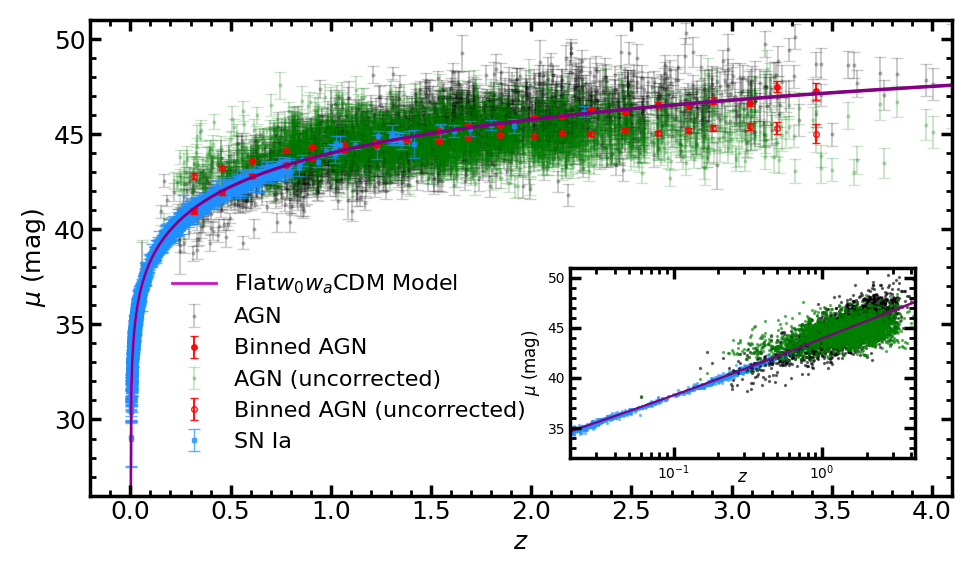

In [85]:
cosmo_model = 'Flatw0waCDM'
sampler_joint, _, mag_corr = run_mcmc_pipeline(df_agn, df_pantheon, cosmo_model=cosmo_model, only_sna=False, completeness=True, use_full_cov=False,
                                     num_warmup=100, num_samples=50)
df_agn['apparent_mag_i_corr'] = mag_corr

from hubble_plotting import plot_hubble
residuals, mu_pred_std = plot_hubble(sampler_joint, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True, completeness=True, show_uncorrected=True)

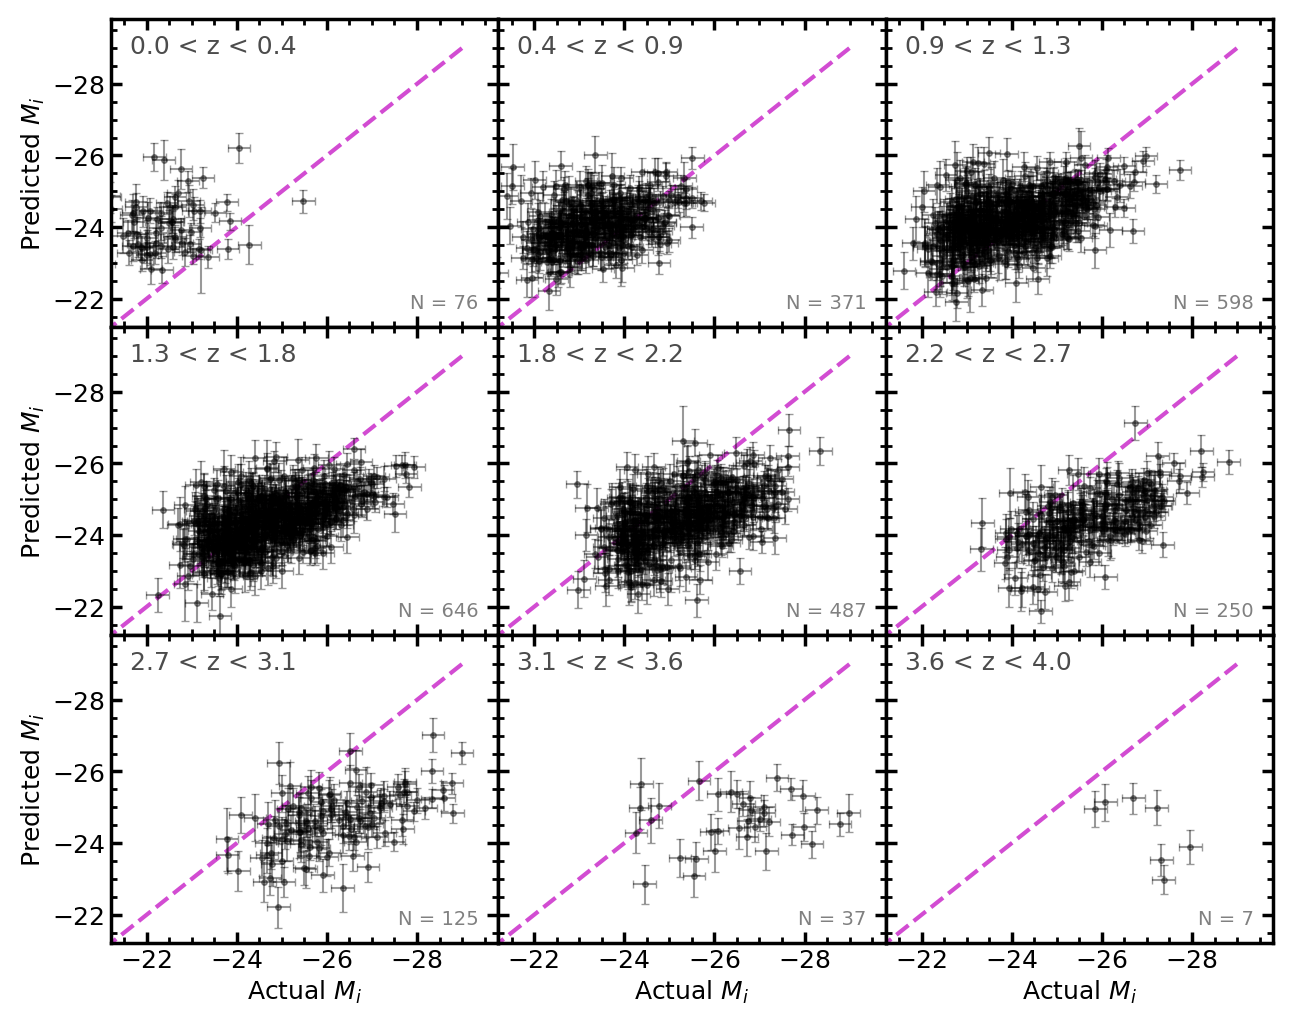

In [169]:
from hubble_plotting import plot_predicted_vs_actual_Mi
plot_predicted_vs_actual_Mi(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)

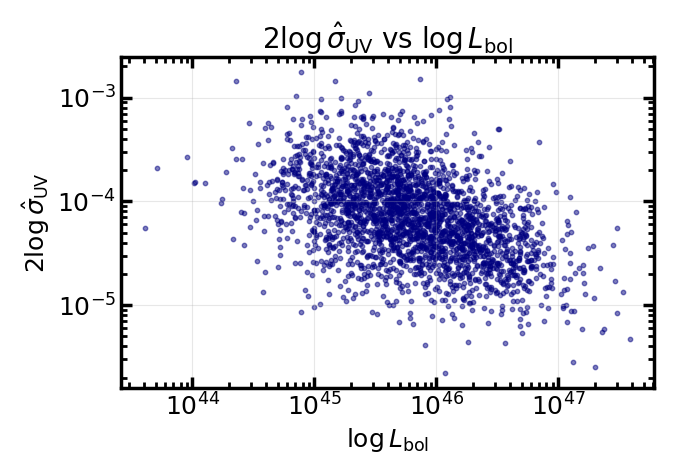

In [95]:
from hubble_plotting import plot_sigma_hat_vs_log_lbol
plot_sigma_hat_vs_log_lbol(df_agn, show=True)

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(df_agn['z'], mag_corr - df_agn['apparent_mag_i'], alpha=0.7, edgecolor='k')
plt.xlabel('Redshift z')
plt.ylabel('mag_corr - apparent_mag_i')
plt.title('mag_corr - apparent_mag_i vs Redshift')
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'mag_corr' is not defined

<Figure size 700x500 with 0 Axes>

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(df_agn['apparent_mag_i'], mag_corr, alpha=0.7, edgecolor='k')
plt.xlabel('Apparent Magnitude (i band)')
plt.ylabel('Corrected Magnitude (mag_corr)')
plt.title('mag_corr vs Apparent Magnitude (i)')
plt.plot([df_agn['apparent_mag_i'].min(), df_agn['apparent_mag_i'].max()],
         [df_agn['apparent_mag_i'].min(), df_agn['apparent_mag_i'].max()],
         color='red', linestyle='--', label='y=x')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'mag_corr' is not defined

<Figure size 700x500 with 0 Axes>

In [7]:
import pickle

with open("sampler_joint_notdz2.pkl", "wb") as f:
    pickle.dump(sampler_joint, f)

In [10]:
# compute delta mag correction
#from hubble_plotting import compute_per_object_delta_mag
#from scipy.interpolate import interp1d
#completeness_params = get_completeness_function_simple(20)
#p_detect, mag_eval, dm = completeness_params

# flat_samples = sampler.get_chain(discard=0, thin=1, flat=True)
# median_theta = np.median(flat_samples, axis=0)

# ll, norm_correction, m_model = log_likelihood(
#     median_theta, cosmo_model,
#     df_agn, df_pantheon, completeness_params,
#     only_sna=False, use_full_cov=False,
#     return_params=True
# )
# delta_mag_arr = apply_delta_mag_correction(df_agn, mu_pred_median, df_agn['z'], norm_correction, p_detect, n_bins=8)
#p_detect_interp = interp1d(mag_eval, p_detect, bounds_error=False, fill_value=0.0)

#delta_mag_arr = compute_per_object_delta_mag(df_agn, p_detect_interp, delta_m=0.01)

from hubble_utils import compute_delta_mag_bias, compute_delta_mag_bias_2d
#delta_mag_arr = compute_delta_mag_bias_2d(df_agn['apparent_mag_i'], 20)
# First, get completeness function and related parameters

completeness2d, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
# Then compute delta mag bias correction
delta_mag_arr = compute_delta_mag_bias_2d(df_agn, completeness2d, mag_centers, z_centers, dm)


plt.figure(figsize=(7, 5))
#delta_mag_arr = delta_mag_arr[delta_mag_arr < 1000]
plt.hist(delta_mag_arr[~np.isnan(delta_mag_arr) & np.isfinite(delta_mag_arr)], bins=30, color='skyblue', edgecolor='k', alpha=0.7)
plt.xlabel('Delta Mag Correction')
plt.ylabel('Count')
plt.title('Histogram of Delta Mag Correction')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

ImportError: cannot import name 'compute_delta_mag_bias_2d' from 'hubble_utils' (/home/dutra/dev/eztaox/tutorials/hubble_utils.py)

In [13]:
from scipy.stats import linregress
from hubble_utils import get_completeness_function_2d, compute_delta_mag_bias_2d_zbins

completeness2d, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
delta_mag_arr, _ = compute_delta_mag_bias_2d_zbins(df_agn, completeness2d, mag_centers, z_centers, dm)

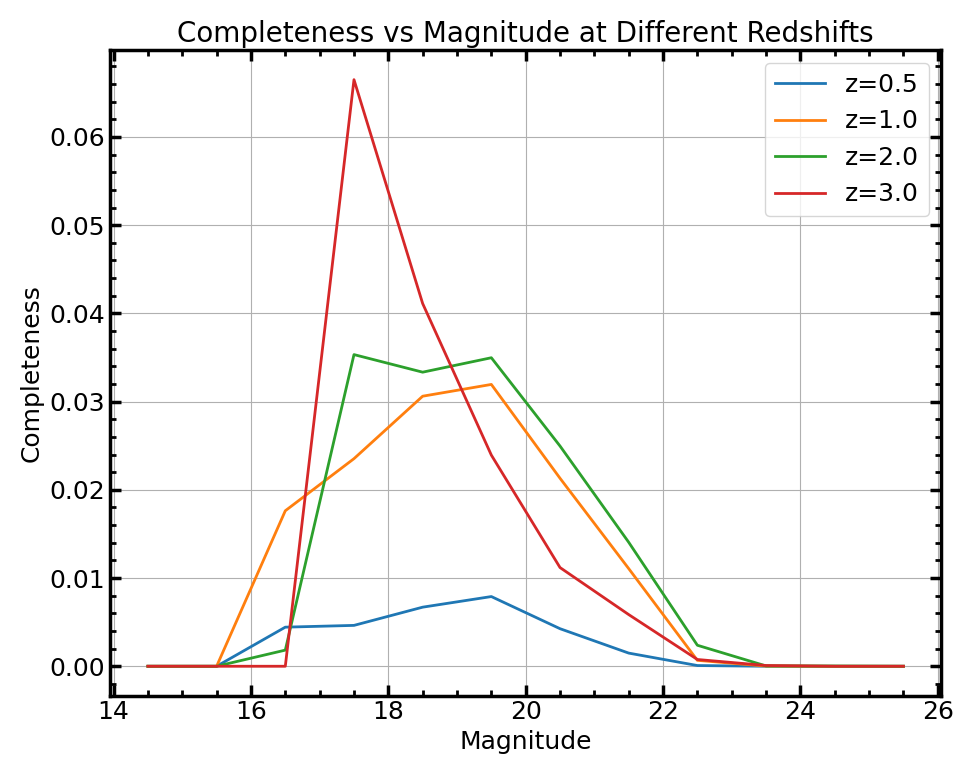

In [14]:
z_vals_to_test = [0.5, 1.0, 2.0, 3.0]
plt.figure()
for zval in z_vals_to_test:
    plt.plot(mag_centers, completeness2d(mag_centers, zval*np.ones_like(mag_centers)), label=f'z={zval}')
plt.xlabel('Magnitude')
plt.ylabel('Completeness')
plt.title('Completeness vs Magnitude at Different Redshifts')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [47]:
df_agn[df_agn['z']>3.5]['apparent_mag_i']

86     21.493103
119    19.802795
121    21.177982
195    20.469383
265    19.852093
345    20.222942
Name: apparent_mag_i, dtype: float32

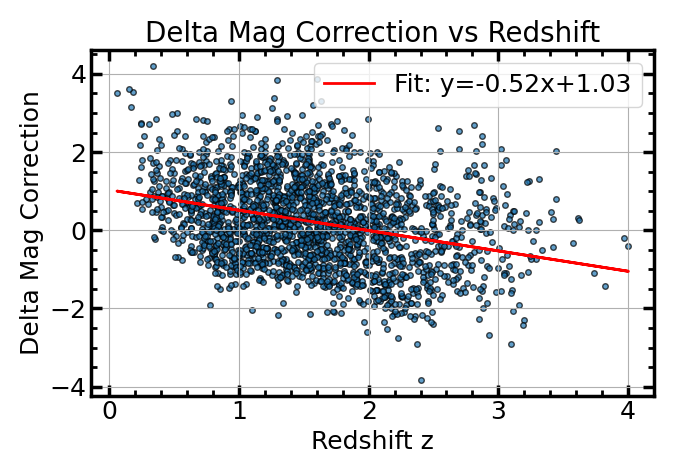

In [7]:

from hubble_utils import get_completeness_function_2d, compute_delta_mag_bias_2d_zbins

completeness2d, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
delta_mag_arr, _ = compute_delta_mag_bias_2d_zbins(df_agn, completeness2d, mag_centers, z_centers, dm)

plt.figure(figsize=(7, 5))
mask = np.isfinite(df_agn['z']) & np.isfinite(delta_mag_arr)
slope, intercept, r_value, p_value, std_err = linregress(df_agn['z'][mask], delta_mag_arr[mask])
plt.plot(df_agn['z'][mask], slope * df_agn['z'][mask] + intercept, color='red', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
plt.legend()
plt.scatter(df_agn['z'], delta_mag_arr, alpha=0.7, edgecolor='k')
plt.xlabel('Redshift z')
plt.ylabel('Delta Mag Correction')
plt.title('Delta Mag Correction vs Redshift')
plt.grid(True)
plt.tight_layout()
plt.show()



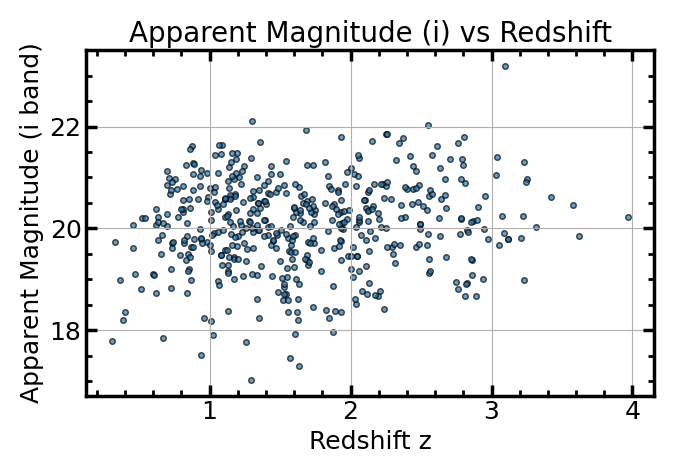

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(df_agn['z'], df_agn['apparent_mag_i'], alpha=0.7, edgecolor='k')
plt.xlabel('Redshift z')
plt.ylabel('Apparent Magnitude (i band)')
plt.title('Apparent Magnitude (i) vs Redshift')
plt.grid(True)
plt.tight_layout()
plt.show()

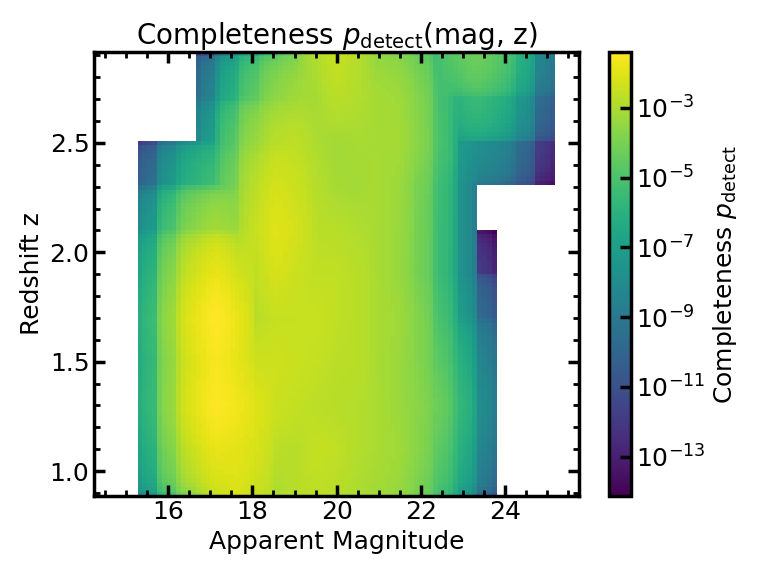

In [43]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))
im = plt.imshow(
    p_grid,
    extent=[mag_grid[0], mag_grid[-1], z_grid[0], z_grid[-1]],
    aspect='auto',
    origin='lower',
    cmap='viridis',
    norm=LogNorm(vmin=np.nanmin(p_grid[p_grid > 0]), vmax=np.nanmax(p_grid))
)
plt.colorbar(im, label='Completeness $p_{\\rm detect}$')
plt.xlabel('Apparent Magnitude')
plt.ylabel('Redshift z')
plt.title('Completeness $p_{\\rm detect}$(mag, z)')
plt.tight_layout()
plt.show()


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_p_detect_for_all_agns(df_agn, p_detect, mag_range=None, n_mag=200, cmap='viridis'):
    mags_agn = df_agn['apparent_mag_i'].values
    zs_agn = df_agn['z'].values

    if mag_range is None:
        min_mag = np.min(mags_agn) - 1
        max_mag = np.max(mags_agn) + 1
    else:
        min_mag, max_mag = mag_range

    mag_grid = np.linspace(min_mag, max_mag, n_mag)
    norm = plt.Normalize(np.min(zs_agn), np.max(zs_agn))
    cmap = plt.get_cmap(cmap)

    fig, ax = plt.subplots(figsize=(7, 5))
    for mag_i, z_i in zip(mags_agn, zs_agn):
        z_arr = np.full_like(mag_grid, z_i, dtype=float)
        p_vals = p_detect(mag_grid, z_arr)
        ax.plot(mag_grid, p_vals, color=cmap(norm(z_i)), alpha=0.5, lw=1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Redshift z')
    ax.set_xlabel('Apparent Magnitude')
    ax.set_ylabel('Completeness $p_{\\rm detect}$')
    ax.set_title('Completeness Function $p_{\\rm detect}$(mag, z) for All AGNs')
    fig.tight_layout()
    plt.show()

plot_p_detect_for_all_agns(df_agn, p_detect)


NameError: name 'p_detect' is not defined

/home/dutra/dev/eztaox/tutorials/hubble_plotting.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


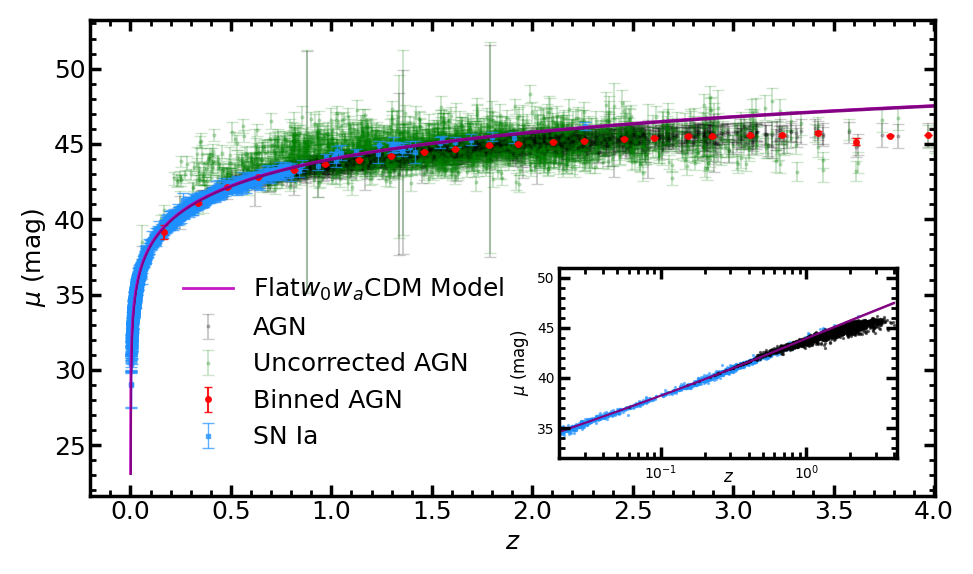

(array([-0.74031882, -0.31631705, -0.33530644, ..., -0.24167741,
        -0.61097548, -0.37919514], shape=(2082,)),
 0       0.476449
 1       0.409552
 2       0.309697
 3       0.470609
 4       0.343745
           ...   
 2077    0.608326
 2078    0.549794
 2079    0.309634
 2080    0.493421
 2081    0.428126
 Length: 2082, dtype: float64)

Generating corner plot: 100%|██████████| 4/4 [00:22<00:00,  5.51s/it]


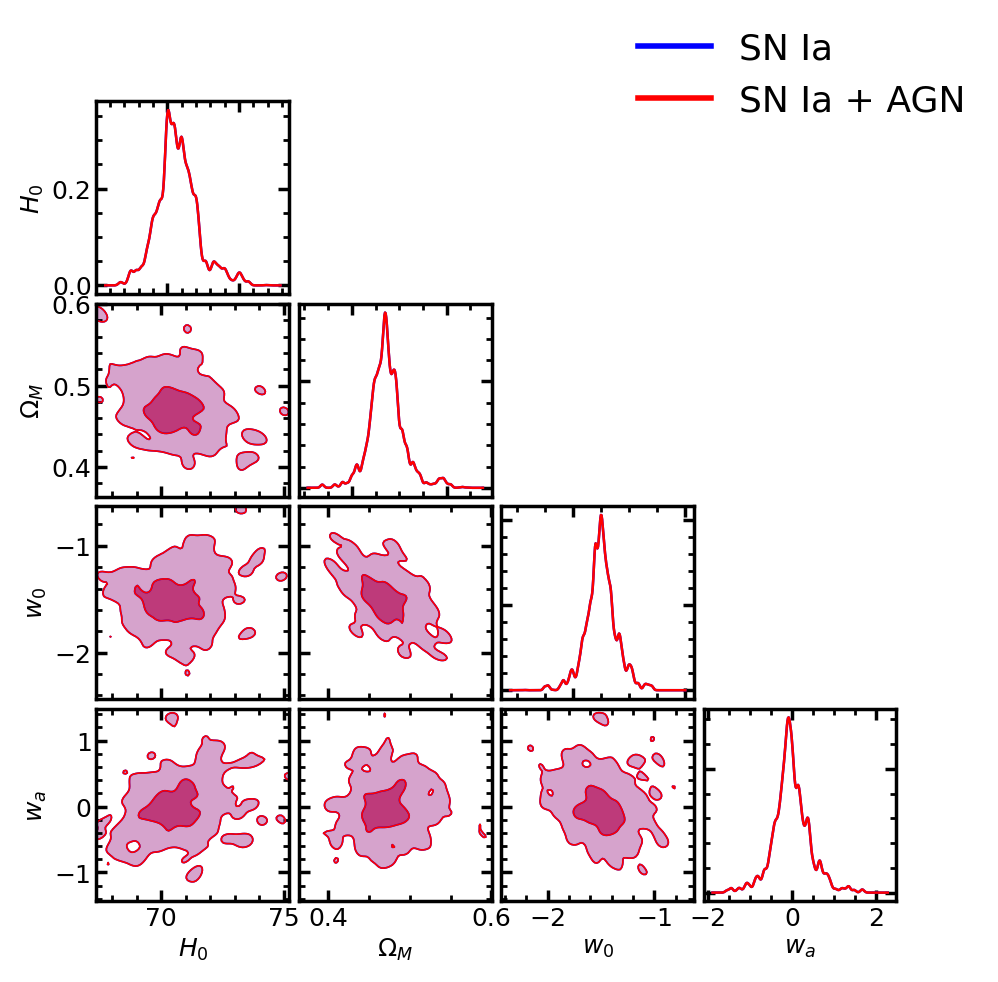

In [6]:
plot_cosmo_corner(sampler_joint, sampler_joint, cosmo_model=cosmo_model, show=True)

In [49]:
from scipy.stats import linregress

from hubble_plotting import plot_predicted_sigma_hat_vs_luminosity
plot_predicted_sigma_hat_vs_luminosity(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)
#plot_predicted_vs_actual_loglbol(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)

IndexError: index -1 is out of bounds for axis 0 with size 0

In [15]:
quasar_list = read_quasars_from_hdf5("data/may8_lc_all.h5")


Reading quasars from HDF5: 100%|██████████| 38825/38825 [02:20<00:00, 275.41it/s]


In [16]:
df_agn = pd.DataFrame(quasar_list)

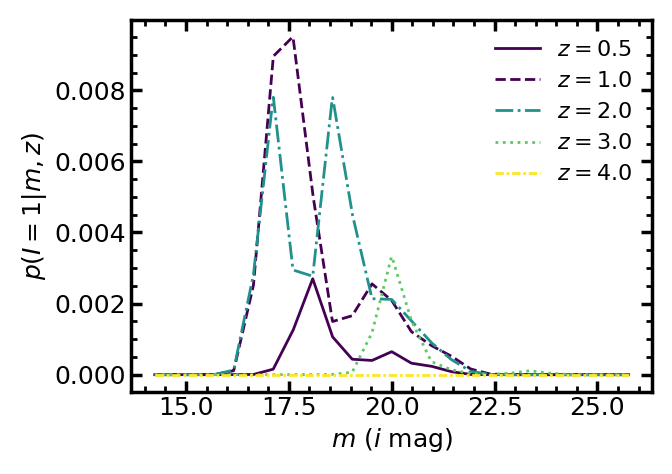

In [9]:
from hubble_utils import *
from hubble_plotting import *

#df_agn = load_quasar_data()
p_detect, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
plot_completeness_vs_mag_at_redshifts(p_detect, mag_centers, z_centers, show=True)

In [ ]:
# Estimate the local slope of ln p(m) near the mean magnitude

mean_mag = np.mean(m_model)
# Evaluate p_detect at mean_mag for a typical z
z_typical = np.median(z)
dm = 0.01
p1 = p_detect(mean_mag, z_typical)
p2 = p_detect(mean_mag + dm, z_typical)
alpha = - (np.log(p2) - np.log(p1)) / dm

# Estimate delta mag
N = len(m_model)
delta_mag = -norm_correction / (N * alpha)
print(f"Estimated Δmag from norm_correction: {delta_mag:.3f} mag")

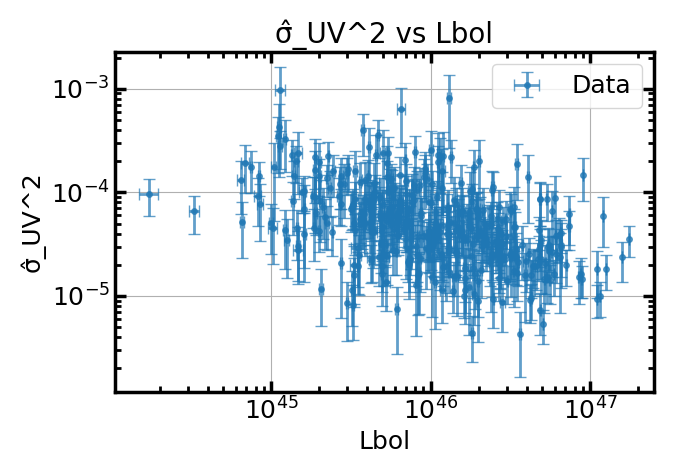

In [66]:
from scipy.stats import linregress

x = 10**df_agn['log_lbol']
y = 10**(2*df_agn['log_sigma_hat_UV'])
yerr = 2 * 10**(2*df_agn['log_sigma_hat_UV']) * df_agn['log_sigma_hat_UV_err'] * np.log(10)
xerr = 10**df_agn['log_lbol'] * df_agn['log_lbol_err'] * np.log(10)

slope, intercept, r_value, p_value, std_err = linregress(x, y)

plt.figure(figsize=(7, 5))
plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', alpha=0.7, label='Data')
#plt.plot(x, slope * x + intercept, color='red', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
plt.xlabel('Lbol')
plt.ylabel('σ̂_UV^2')
plt.title('σ̂_UV^2 vs Lbol')
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.yscale('log')   
plt.tight_layout()
plt.show()


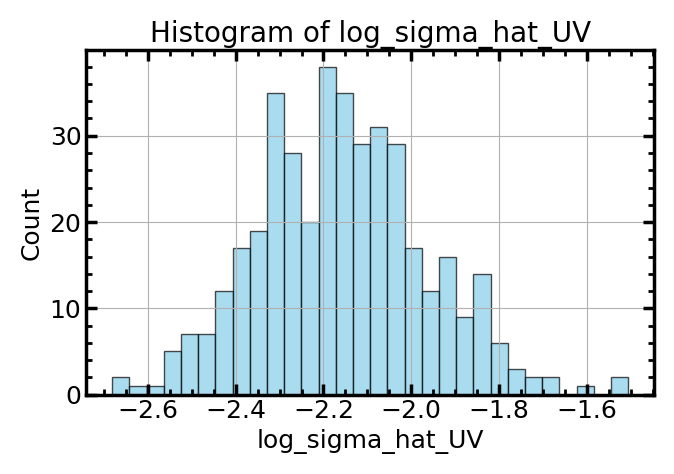

In [63]:
plt.figure(figsize=(7, 5))
plt.hist(df_agn['log_sigma_hat_UV'], bins=30, alpha=0.7, color='skyblue', edgecolor='k')
plt.xlabel('log_sigma_hat_UV')
plt.ylabel('Count')
plt.title('Histogram of log_sigma_hat_UV')
plt.grid(True)
plt.tight_layout()
plt.show()

400


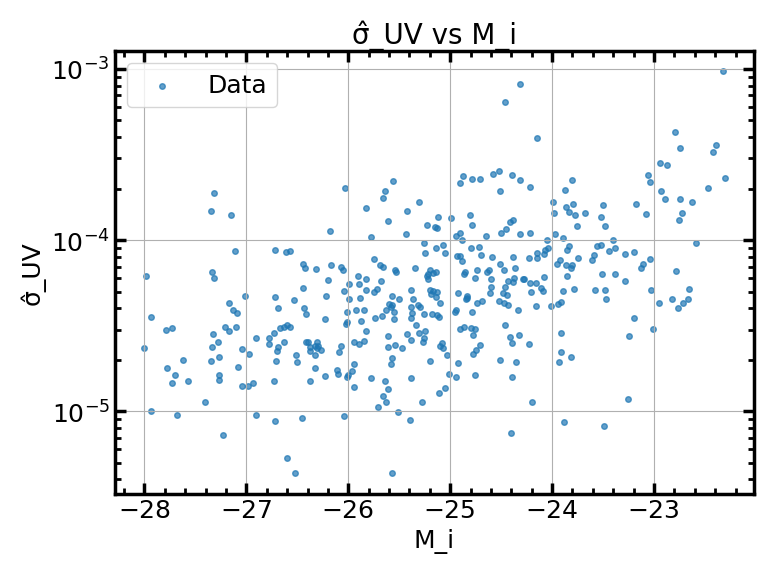

In [62]:
from scipy.stats import linregress

x = df_agn['M_i']
y = 10**(2*df_agn['log_sigma_hat_UV'])
print(len(y))
slope, intercept, r_value, p_value, std_err = linregress(x, y)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, label='Data')
#plt.plot(x, slope * x + intercept, color='red', label=f'Fit: y={slope:.4f}x+{intercept:.4f}')
plt.xlabel('M_i')
plt.ylabel('σ̂_UV')
plt.title('σ̂_UV vs M_i')
plt.grid(True)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

ValueError: 'xerr' must not contain negative values

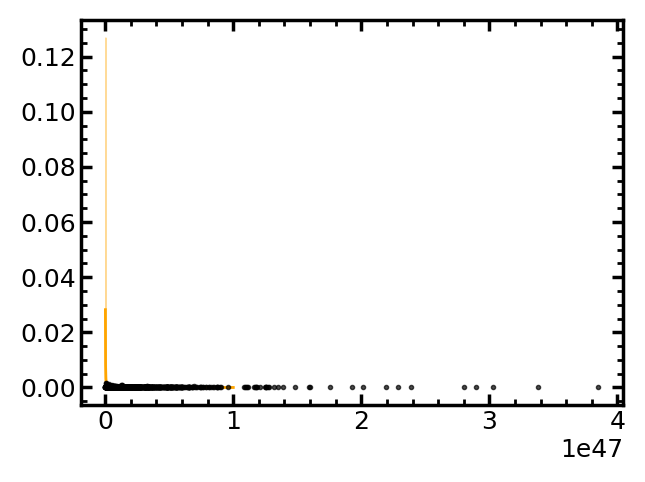

In [99]:
print(slopes)

[-0.31936564 -0.31936564 -0.31936564 ... -0.31936564 -0.31936564
 -0.31936564]


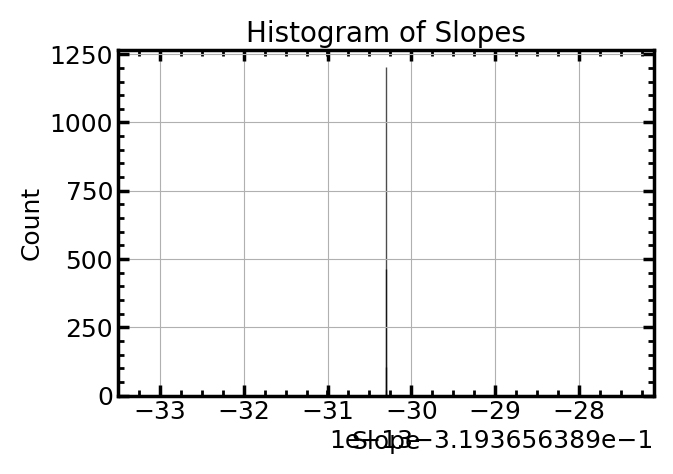

In [98]:
plt.figure(figsize=(7, 5))
plt.hist(slopes, bins=5, color='skyblue', edgecolor='k', alpha=0.7)
plt.xlabel('Slope')
plt.ylabel('Count')
plt.title('Histogram of Slopes')
plt.grid(True)
plt.tight_layout()
plt.show()